In [ ]:
%%capture
!pip install ultralytics roboflow

# Get Dataset

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="wxNcHzEfIL34aorsb2S2")
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
version = project.version(12)
dataset = version.download("yolov5")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-12 in yolov5pytorch:: 100%|██████████| 756/756 [00:00<00:00, 1628.11it/s]


In [ ]:
dataset.location

'/content/football-players-detection-12'

In [ ]:
import shutil

shutil.move('football-players-detection-12/test',
            'football-players-detection-12/football-players-detection-12/test')

shutil.move('football-players-detection-12/train',
            'football-players-detection-12/football-players-detection-12/train')

shutil.move('football-players-detection-12/valid',
            'football-players-detection-12/football-players-detection-12/valid')

'football-players-detection-12/football-players-detection-12/valid'

# Custom Training

In [ ]:
!yolo task=detect mode=train model=yolov5mu.pt data={dataset.location}/data.yaml batch=6 epochs=50 imgsz=1280 plots=True

100% 48.2M/48.2M [00:00<00:00, 94.0MB/s]
Ultralytics YOLOv8.2.82 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov5mu.pt, data=/content/football-players-detection-12/data.yaml, epochs=50, time=None, patience=100, batch=6, imgsz=1280, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf

In [ ]:
from google.colab import files
files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
from IPython import display
display.clear_output()

from IPython.display import display, Image

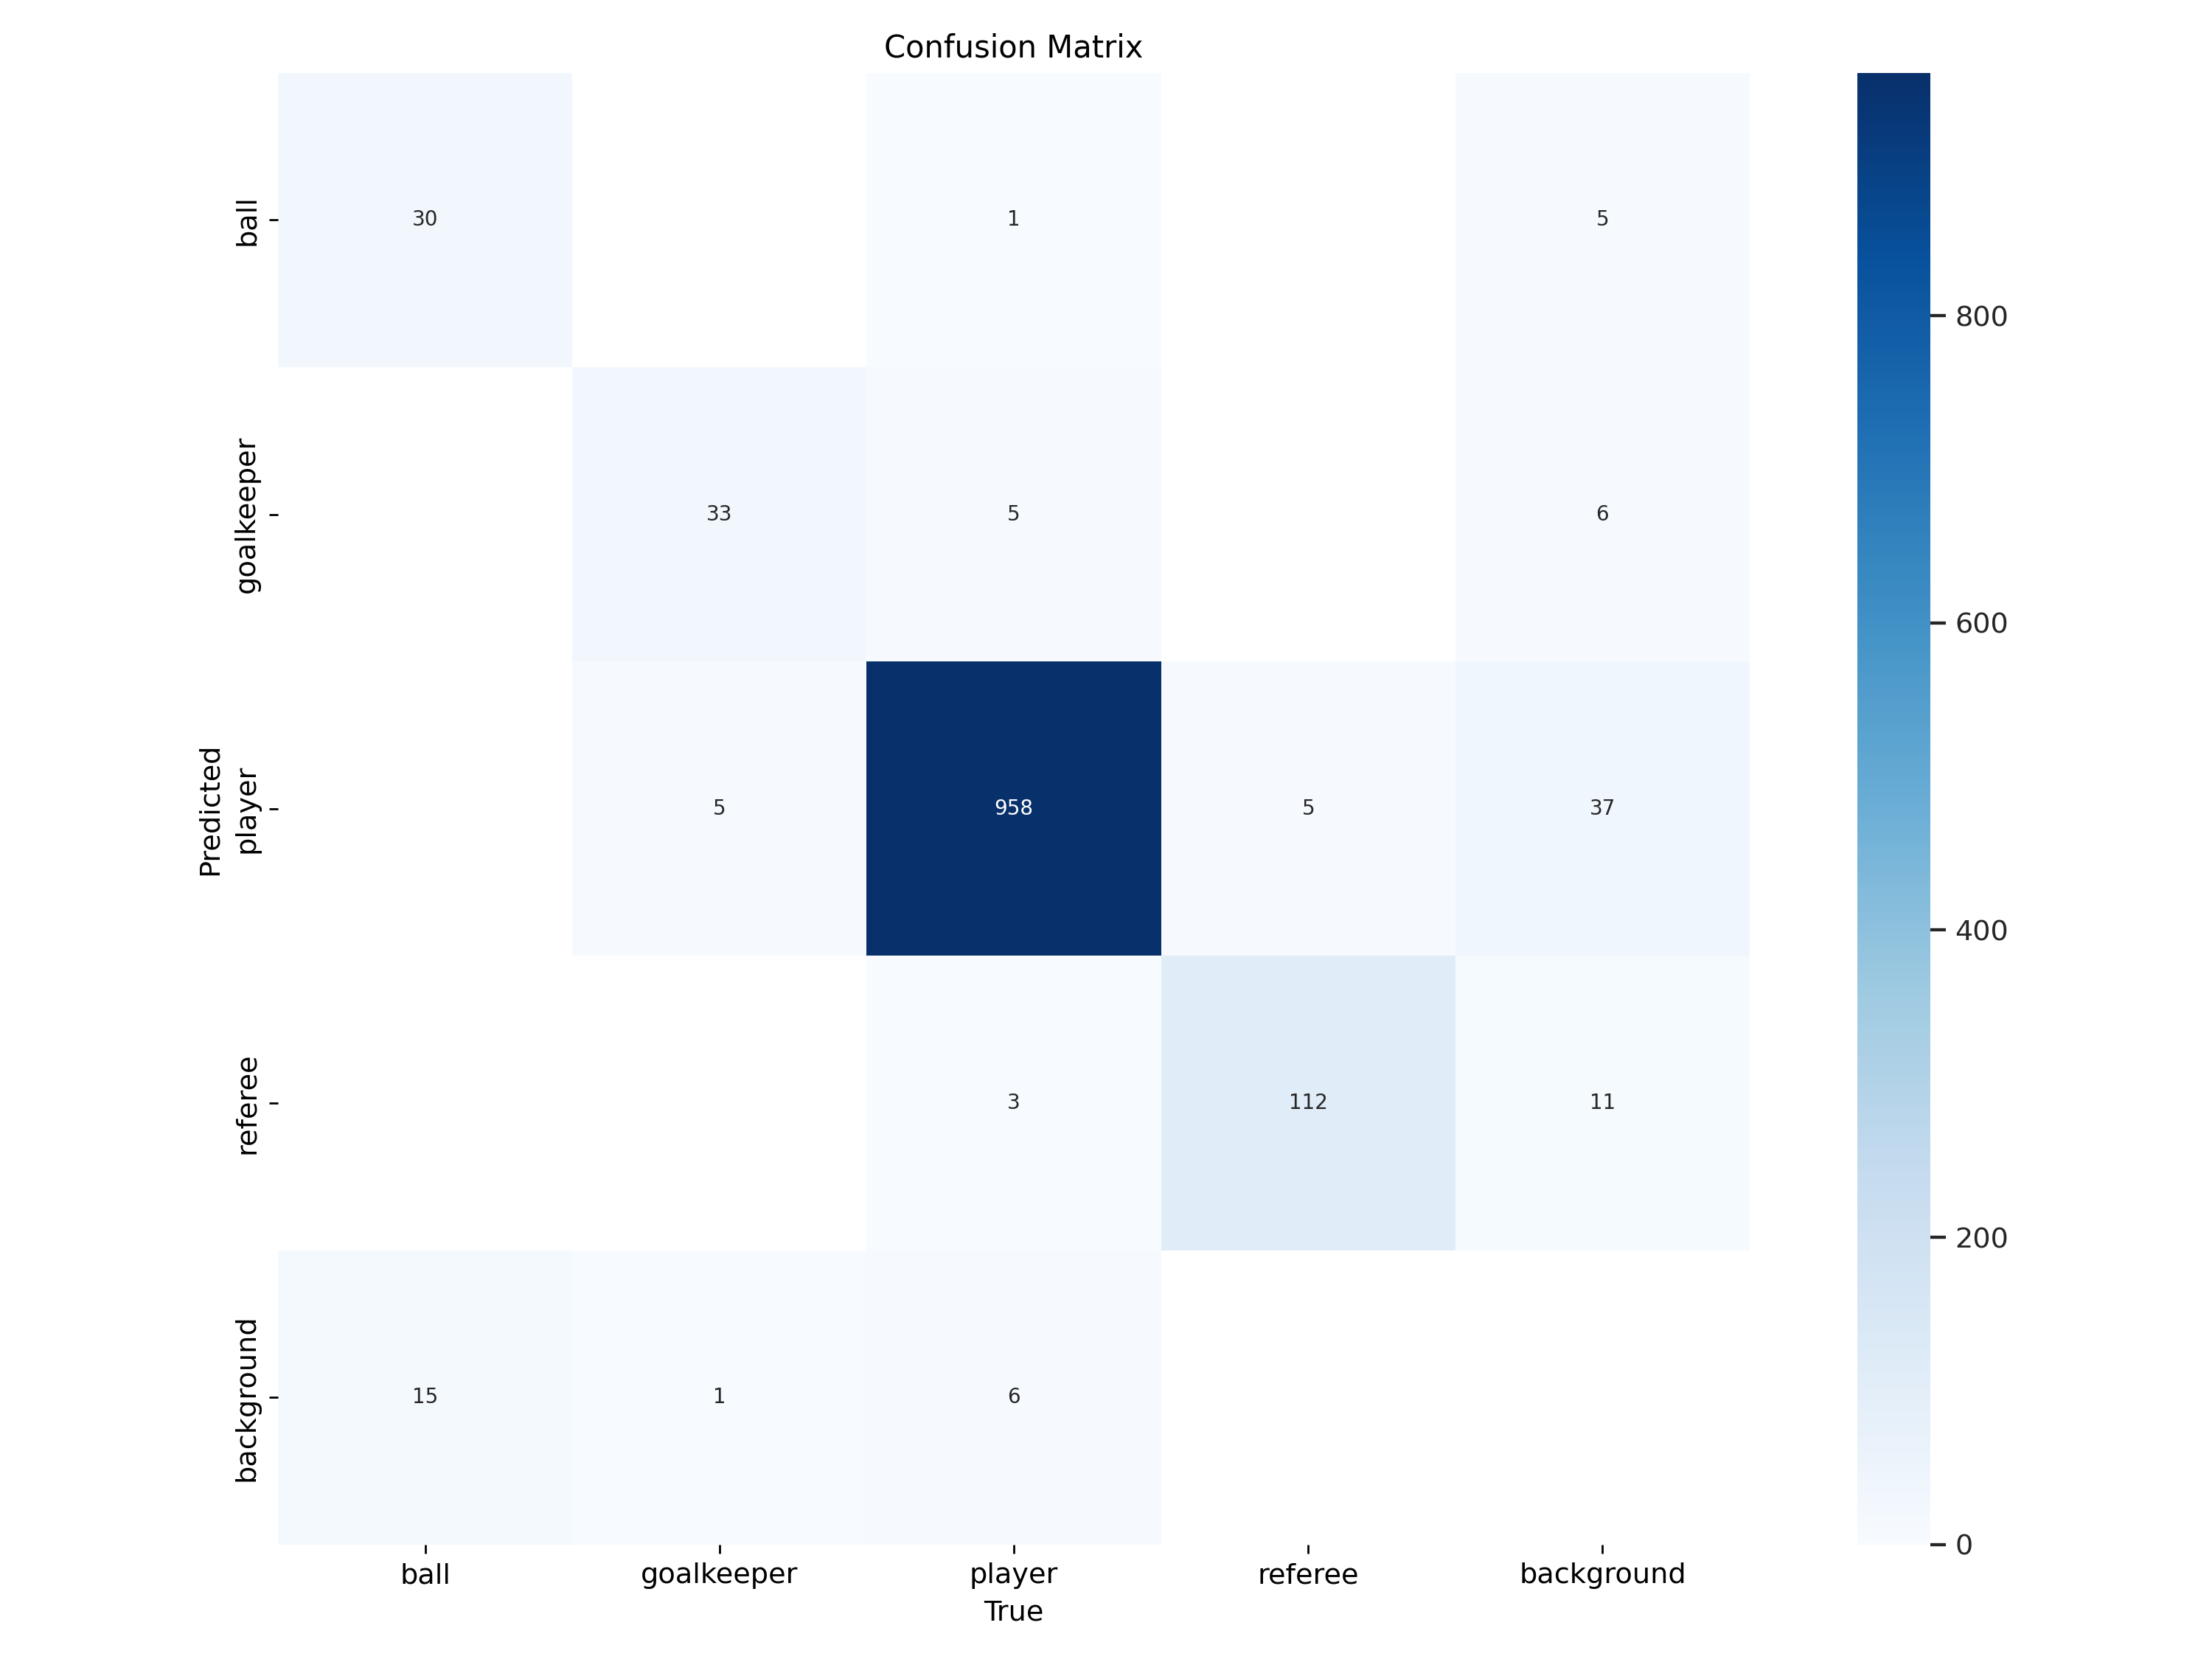

In [ ]:
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=800)

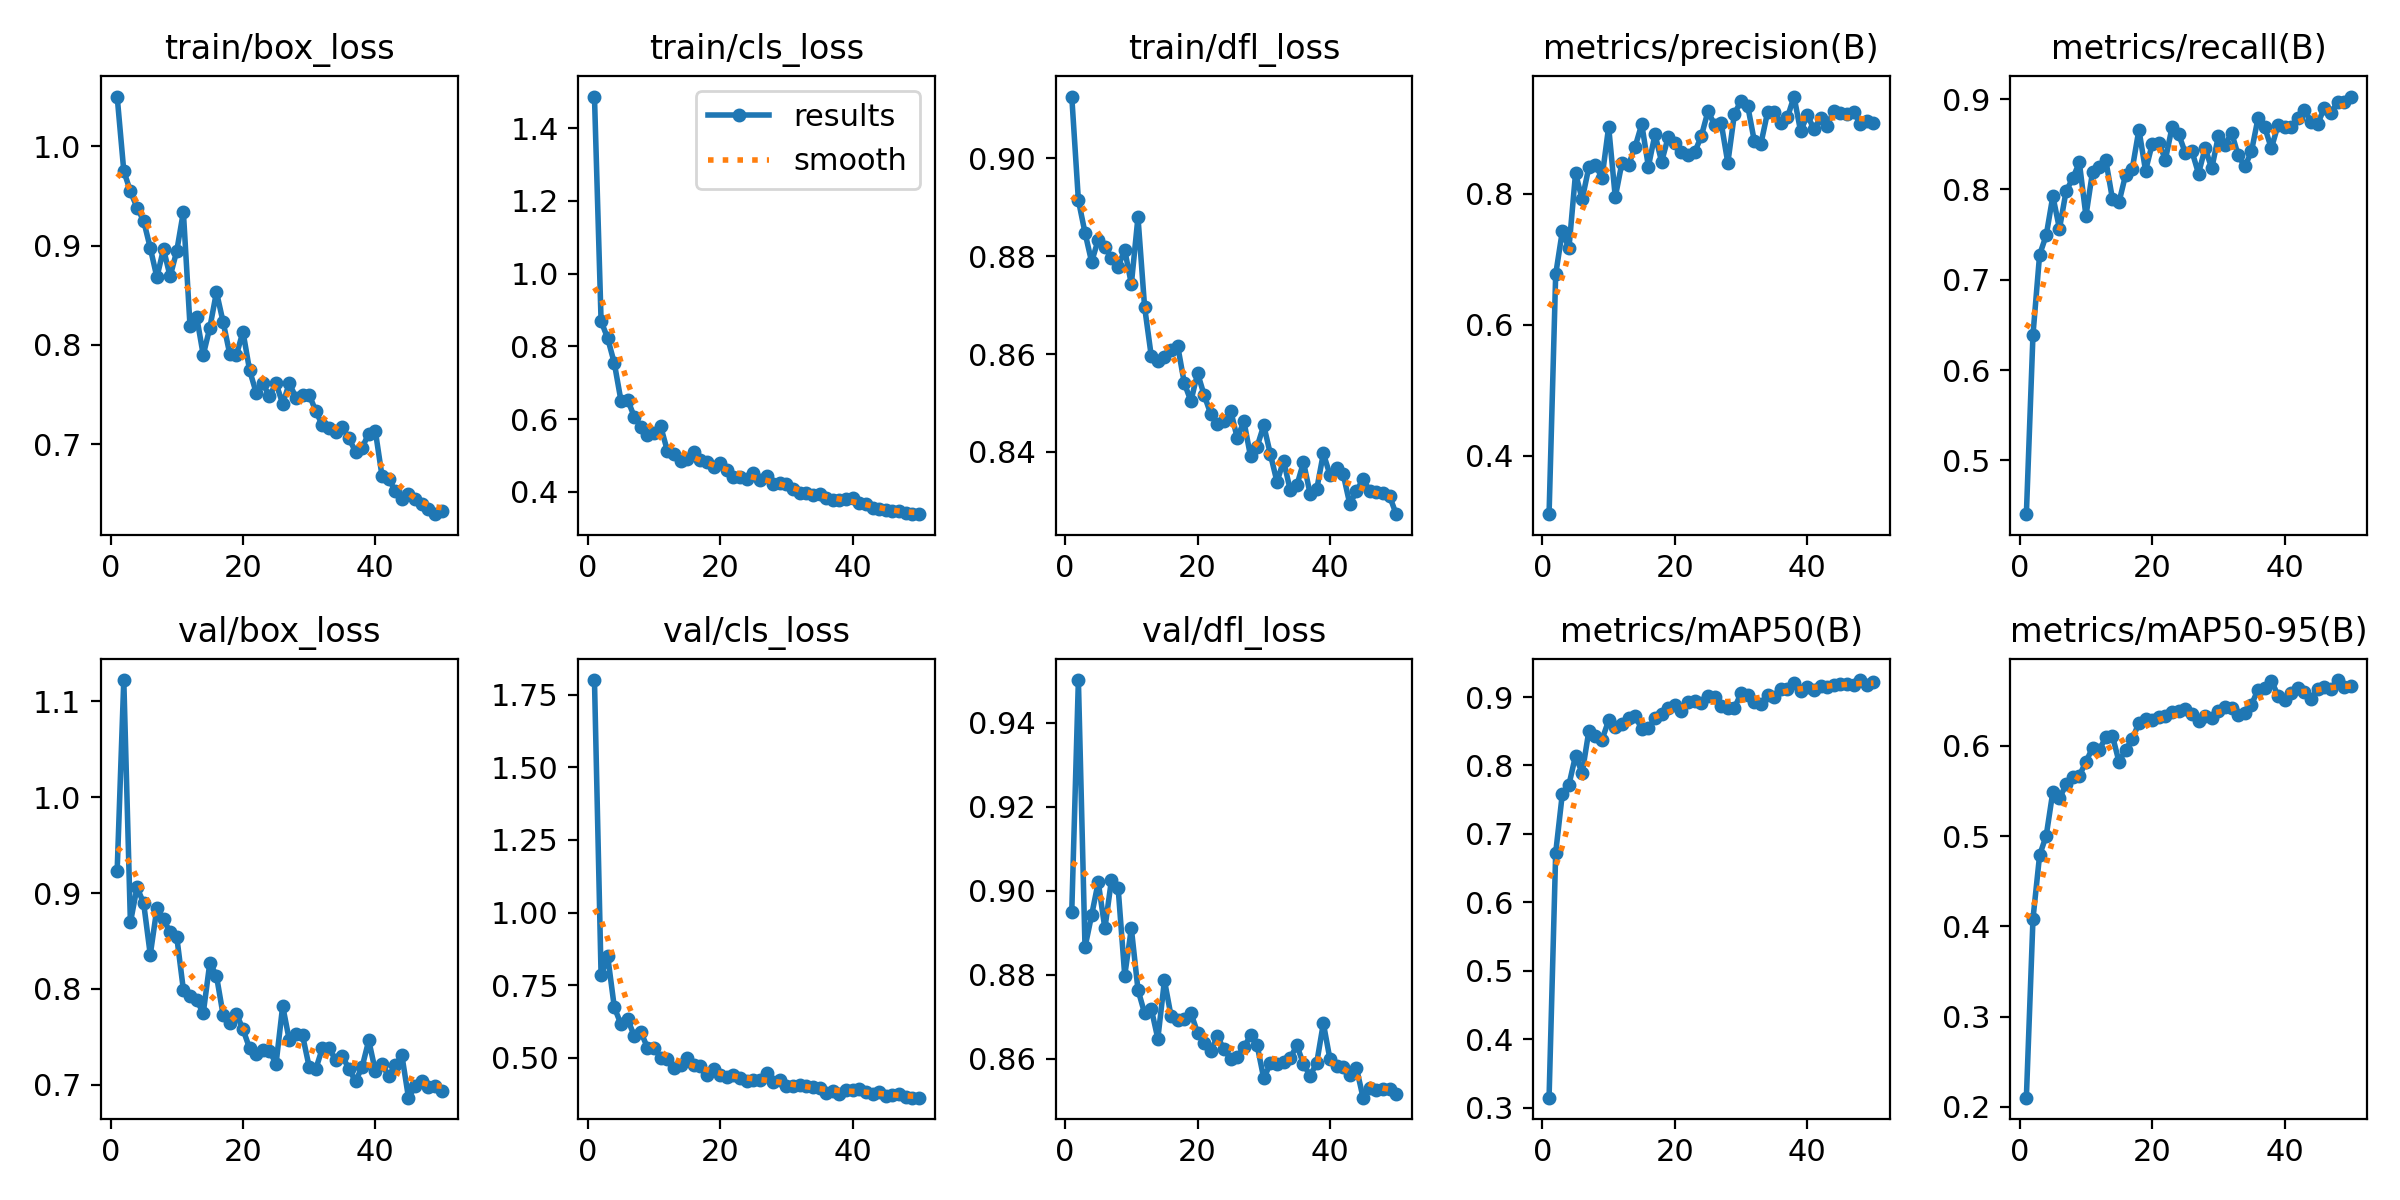

In [ ]:
Image(filename=f'{HOME}/runs/detect/train/results.png', width=800)

# Validate Custom Model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml imgsz=1280

Ultralytics YOLOv8.2.82 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv5m summary (fused): 248 layers, 25,047,532 parameters, 0 gradients, 64.0 GFLOPs
val: Scanning /content/football-players-detection-12/football-players-detection-12/valid/labels.cache... 49 images, 0 backgrounds, 0 corrupt: 100% 49/49 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 4/4 [00:14<00:00,  3.71s/it]
                   all         49       1174      0.907      0.897      0.925       0.68
                  ball         45         45      0.879      0.667       0.76      0.359
            goalkeeper         38         39      0.839      0.949      0.958      0.762
                player         49        973       0.97       0.99      0.994      0.855
               referee         49        117      0.939      0.983      0.988      0.744
Speed: 54.7ms preprocess, 97.2ms inference, 0.5ms loss, 46.1ms postprocess per image
Resu

# Inference with Custom Model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/football-players-detection-12/test/images imgsz=1280 save=True

Ultralytics YOLOv8.2.82 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv5m summary (fused): 248 layers, 25,047,532 parameters, 0 gradients, 64.0 GFLOPs

image 1/25 /content/football-players-detection-12/football-players-detection-12/test/images/08fd33_3_6_png.rf.bee65249830b3e263ebe95a999f39e34.jpg: 1280x1280 1 ball, 20 players, 2 referees, 81.3ms
image 2/25 /content/football-players-detection-12/football-players-detection-12/test/images/08fd33_9_3_png.rf.f5439a0d252bbf8a8ce96169744b49b6.jpg: 1280x1280 20 players, 1 referee, 68.5ms
image 3/25 /content/football-players-detection-12/football-players-detection-12/test/images/40cd38_7_6_png.rf.dc7957fcce915bc48188f18a7b19455b.jpg: 1280x1280 1 ball, 1 goalkeeper, 20 players, 1 referee, 69.5ms
image 4/25 /content/football-players-detection-12/football-players-detection-12/test/images/42ba34_1_5_png.rf.927d602c034ce2997f58f62a7c1245ba.jpg: 1280x1280 1 ball, 1 goalkeeper, 20 players, 2 referees, 61.4ms
image 5/25 /content/f

#  Let's take a look at few results

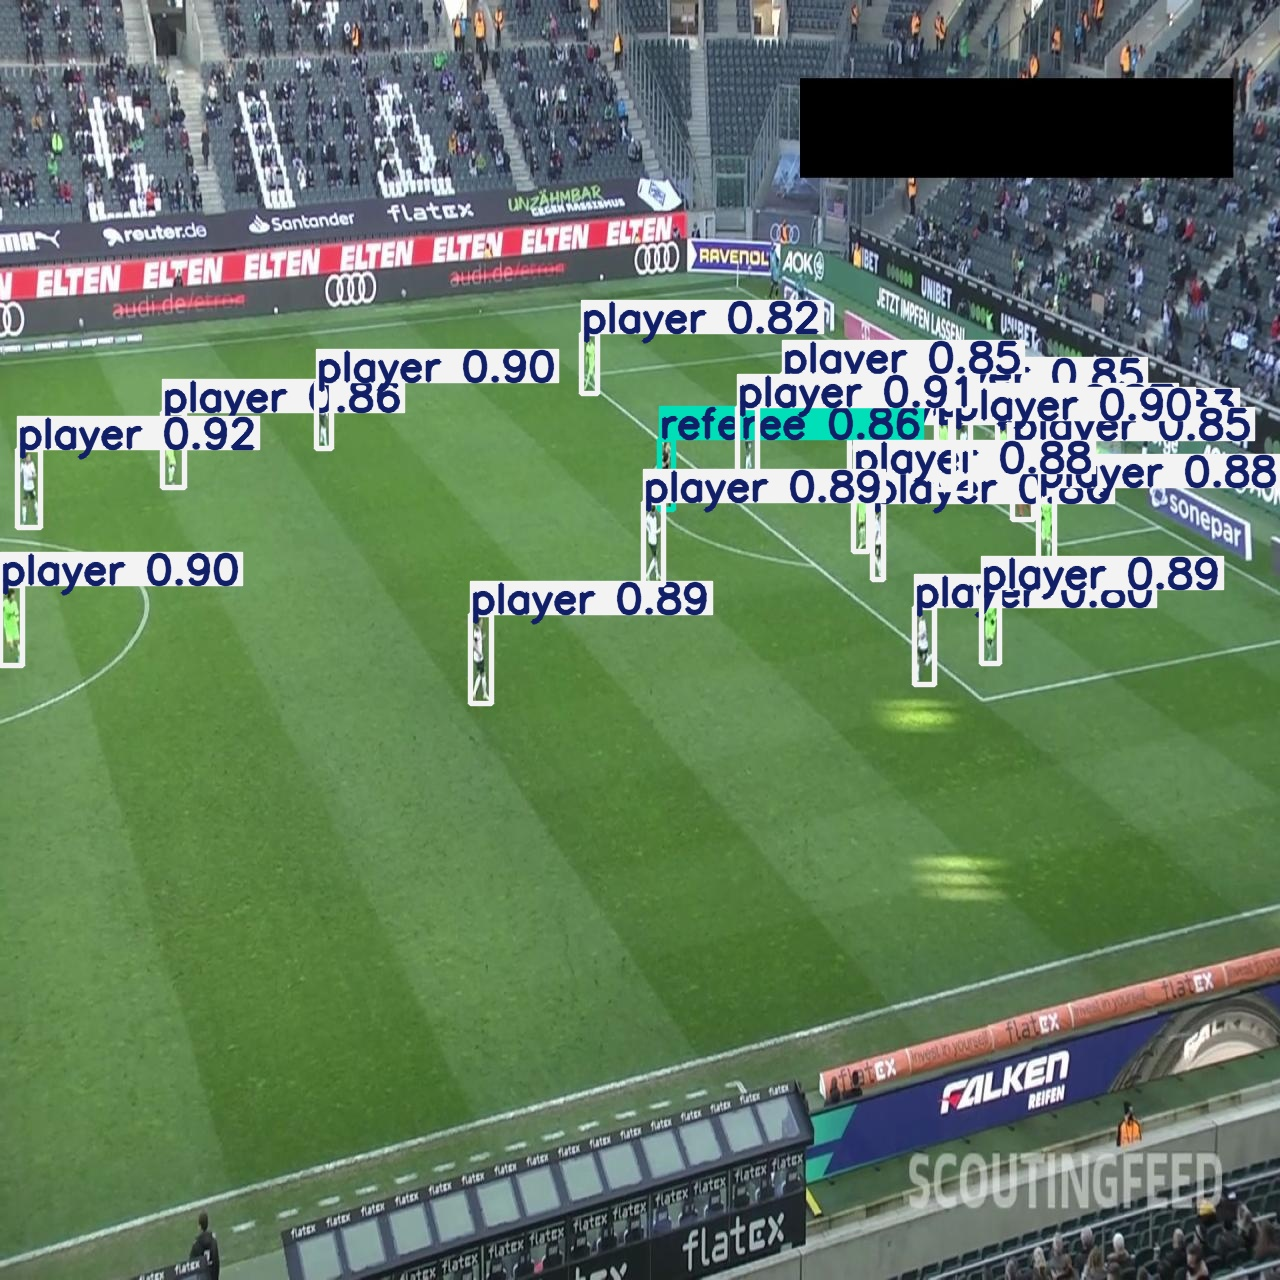

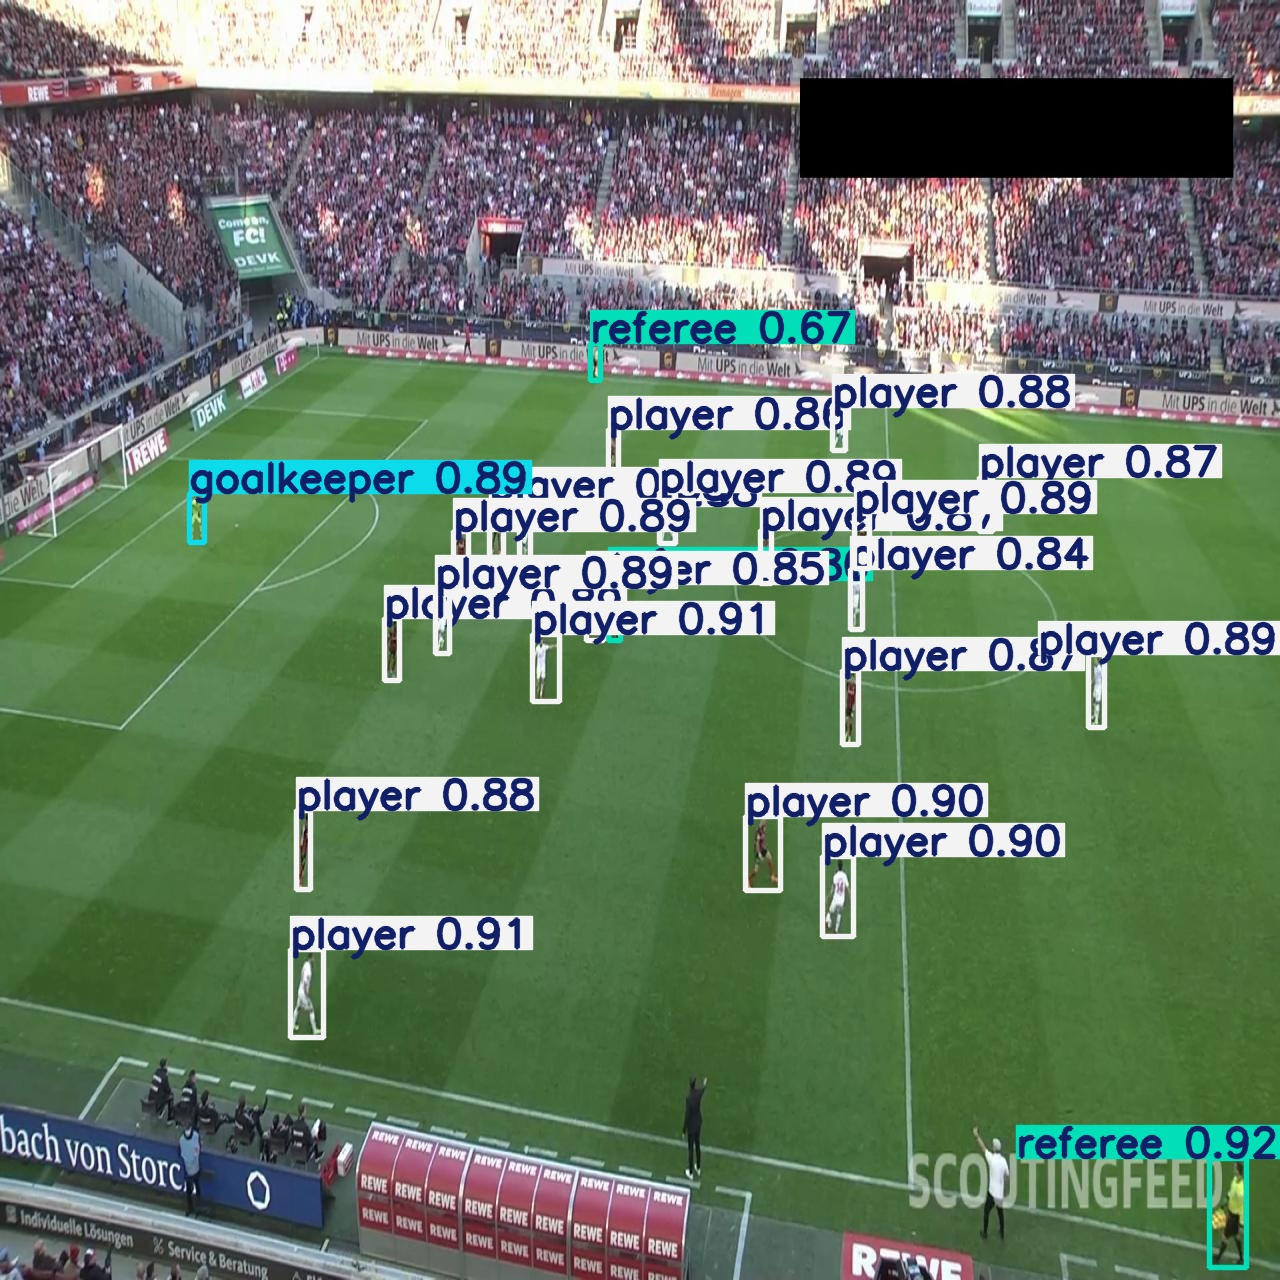

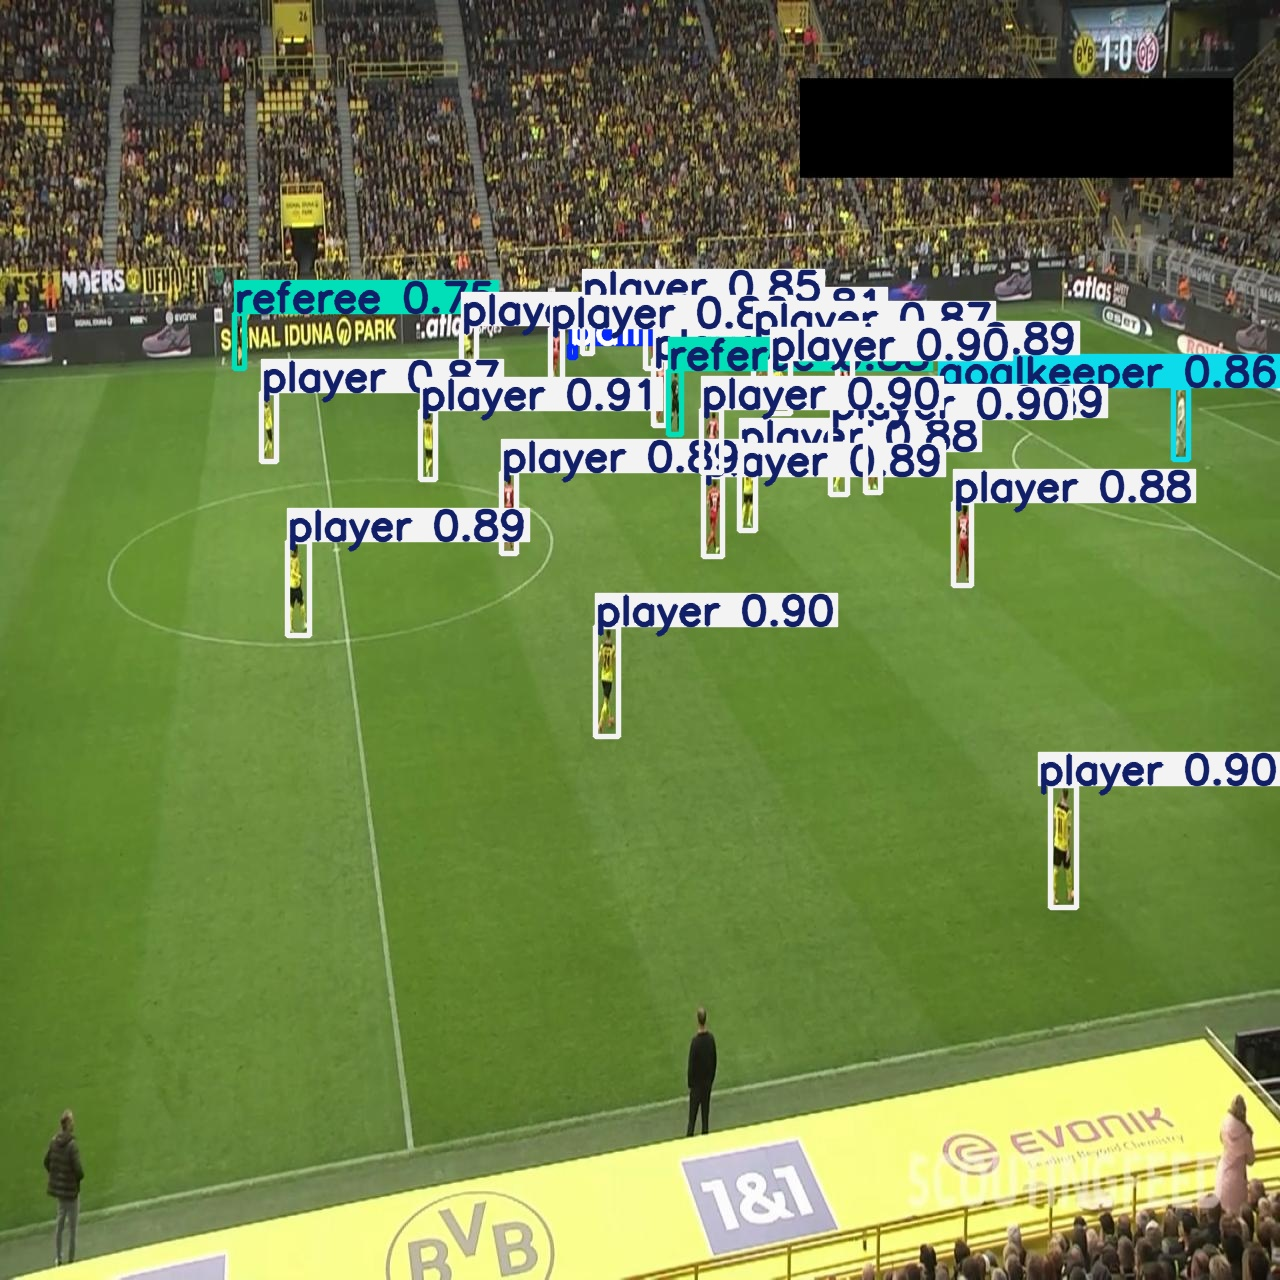

In [ ]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=800))
    print("\n")